# Лабораторная работа: Иерархическая кластеризация

## 1. Формулировка задания

1. Разработать программу, выполняющую **иерархическую кластеризацию** заданного набора
   данных. Параметры программы — набор данных и используемая мера схожести кластеров
   (*Single linkage*, *Complete linkage*, *Group average* или *Ward distance*). Мера
   схожести объектов — евклидово расстояние.
2. Программа должна выполнять визуализацию полученных результатов в виде **дендрограммы**.
3. Провести эксперименты на наборе данных из задания 1 (`customers`).
4. Сравнить полученные результаты с результатами задания 1 (k-Means и k-Medoids).
5. Провести эксперименты, варьируя меру схожести кластеров, и сравнить результаты,
   полученные для различных мер, между собой.

## 2. Набор данных и подготовка

Используется тот же набор `customers` (850 клиентов банка), что и в задании 1, и та же
подготовка: семь содержательных числовых признаков, z-нормировка. Служебные `Row` и
`CustomerId` исключены, атрибут `Defaulted` (факт банкротства) не участвует в
кластеризации и используется только для содержательной проверки результата.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42
FEATURES = ["Age", "Education", "YearsEmployed", "Income",
            "CardDebt", "OtherDebt", "DebtIncomeRatio"]

df = pd.read_csv("customers.csv")
X_raw = df[FEATURES].to_numpy(float)
MEAN, STD = X_raw.mean(axis=0), X_raw.std(axis=0)
X = (X_raw - MEAN) / STD

print(f"Объектов: {X.shape[0]}, признаков: {X.shape[1]}")
df.head()

Объектов: 850, признаков: 7


,Row,CustomerId,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


## 3. Реализация иерархической кластеризации

Используется **агломеративная** схема: сначала каждый объект образует собственный кластер,
затем на каждом шаге объединяются два ближайших кластера, и так до единственного кластера.
Всего выполняется $n - 1$ слияние; история слияний и образует иерархию.

Мера схожести объектов фиксирована — евклидово расстояние
$d(x, y) = \sqrt{\sum_j (x_j - y_j)^2}$. Мера схожести **кластеров** задаётся параметром
(здесь $n_i = |C_i|$ — число объектов в кластере, $\mu_i$ — его центроид):

| Мера | Расстояние между кластерами $C_i$ и $C_j$ |
|---|---|
| Single linkage | $\min\limits_{x \in C_i,\, y \in C_j} d(x, y)$ — расстояние между ближайшими объектами |
| Complete linkage | $\max\limits_{x \in C_i,\, y \in C_j} d(x, y)$ — расстояние между самыми далёкими объектами |
| Group average | $\dfrac{1}{n_i n_j} \sum\limits_{x \in C_i} \sum\limits_{y \in C_j} d(x, y)$ — среднее попарное расстояние |
| Ward distance | прирост внутрикластерной суммы квадратов при слиянии: $\dfrac{n_i n_j}{n_i + n_j} \, d^2(\mu_i, \mu_j)$ |

### Формула Ланса — Уильямса

Пересчитывать расстояния по определению после каждого слияния дорого. Все четыре меры
подчиняются единому рекуррентному соотношению Ланса — Уильямса: расстояние от нового
кластера $C_i \cup C_j$ до кластера $C_k$ выражается через уже известные расстояния

$$d(C_i \cup C_j, C_k) = \alpha_i\, d(C_i, C_k) + \alpha_j\, d(C_j, C_k)
  + \beta\, d(C_i, C_j) + \gamma\, |d(C_i, C_k) - d(C_j, C_k)|,$$

где коэффициенты зависят только от выбранной меры и размеров кластеров
($n_i = |C_i|$, $n = n_i + n_j + n_k$):

| Мера | $\alpha_i$ | $\alpha_j$ | $\beta$ | $\gamma$ |
|---|---|---|---|---|
| Single linkage | $1/2$ | $1/2$ | $0$ | $-1/2$ |
| Complete linkage | $1/2$ | $1/2$ | $0$ | $+1/2$ |
| Group average | $\dfrac{n_i}{n_i + n_j}$ | $\dfrac{n_j}{n_i + n_j}$ | $0$ | $0$ |
| Ward distance | $\dfrac{n_i + n_k}{n}$ | $\dfrac{n_j + n_k}{n}$ | $-\dfrac{n_k}{n}$ | $0$ |

Благодаря этому один шаг стоит $O(n)$ вместо полного перебора пар объектов, а весь
алгоритм — $O(n^2)$ памяти и $O(n^3)$ в худшем случае по времени (на 850 объектах — доли
секунды). Для меры Ward рекуррентность справедлива для **квадратов** расстояний, поэтому
матрица возводится в квадрат заранее, а высота слияния извлекается обратно корнем.

### Формат результата

Результат — матрица слияний $Z$ размера $(n-1) \times 4$: в строке $t$ записаны номера двух
объединяемых узлов, расстояние между ними (высота слияния) и размер получившегося
кластера. Исходные объекты имеют номера $0..n-1$, узел, созданный на шаге $t$, — номер
$n + t$. Это стандартное представление дендрограммы.

In [2]:
LINKAGES = ["single", "complete", "average", "ward"]
LINKAGE_LABEL = {"single": "Single linkage", "complete": "Complete linkage",
                 "average": "Group average", "ward": "Ward distance"}


def pairwise_distances(A, B):
    """Матрица евклидовых расстояний между строками A и строками B."""
    d2 = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1)
    return np.sqrt(np.maximum(d2, 0.0))


def hierarchical_clustering(X, linkage="ward"):
    """
    Агломеративная иерархическая кластеризация.
      X       — набор данных
      linkage — мера схожести кластеров: single | complete | average | ward
    Возвращает матрицу слияний Z размера (n-1) x 4:
      [номер узла 1, номер узла 2, высота слияния, размер нового кластера].
    """
    if linkage not in LINKAGES:
        raise ValueError(f"мера схожести должна быть одной из {LINKAGES}")

    n = len(X)
    D = pairwise_distances(X, X)
    if linkage == "ward":
        D = D ** 2                      # рекуррентность Ward — для квадратов расстояний
    np.fill_diagonal(D, np.inf)

    size = np.ones(n)                   # размеры текущих кластеров
    node = np.arange(n)                 # номер узла дерева для каждой строки матрицы
    active = np.ones(n, dtype=bool)
    Z = np.empty((n - 1, 4))

    for step in range(n - 1):
        i, j = np.unravel_index(D.argmin(), D.shape)   # ближайшая пара кластеров
        if i > j:
            i, j = j, i
        d_ij = D[i, j]
        n_i, n_j, n_k = size[i], size[j], size
        Z[step] = [node[i], node[j],
                   np.sqrt(d_ij) if linkage == "ward" else d_ij, n_i + n_j]

        d_ik, d_jk = D[i].copy(), D[j].copy()          # формула Ланса — Уильямса
        if linkage == "single":
            d_new = np.minimum(d_ik, d_jk)
        elif linkage == "complete":
            d_new = np.maximum(d_ik, d_jk)
        elif linkage == "average":
            d_new = (n_i * d_ik + n_j * d_jk) / (n_i + n_j)
        else:
            total = n_i + n_j + n_k
            d_new = ((n_i + n_k) * d_ik + (n_j + n_k) * d_jk - n_k * d_ij) / total

        d_new[~active] = np.inf
        d_new[i] = d_new[j] = np.inf
        D[i, :] = D[:, i] = d_new                      # строка i — новый кластер
        D[j, :] = D[:, j] = np.inf                     # строка j выбывает
        size[i], node[i], active[j] = n_i + n_j, n + step, False

    return Z

In [3]:
def cut_tree(Z, k):
    """Срез дендрограммы на k кластеров: отменяются k-1 последних слияний.
    Кластеры нумеруются по убыванию размера."""
    n = len(Z) + 1
    members = {i: [i] for i in range(n)}
    for step, (a, b, _, _) in enumerate(Z[:n - k]):
        members[n + step] = members.pop(int(a)) + members.pop(int(b))

    labels = np.empty(n, dtype=int)
    for label, (_, group) in enumerate(sorted(members.items(), key=lambda p: -len(p[1]))):
        labels[group] = label
    return labels


def cluster_errors(X, labels):
    """SSE (до центроидов) и E (до медоидов) — те же меры ошибки, что в задании 1."""
    sse = total = 0.0
    for j in np.unique(labels):
        P = X[labels == j]
        sse += ((P - P.mean(axis=0)) ** 2).sum()
        D = pairwise_distances(P, P)
        total += D.sum(axis=0).min()
    return sse, total


trees = {}
for linkage in LINKAGES:
    t0 = time.perf_counter()
    trees[linkage] = hierarchical_clustering(X, linkage)
    Z = trees[linkage]
    monotone = bool(np.all(np.diff(Z[:, 2]) >= -1e-9))
    print(f"{LINKAGE_LABEL[linkage]:<18} построено за {time.perf_counter() - t0:.2f} с, "
          f"слияний {len(Z)}, высота корня {Z[-1, 2]:6.2f}, монотонность: {monotone}")

Single linkage     построено за 0.17 с, слияний 849, высота корня   6.74, монотонность: True


Complete linkage   построено за 0.18 с, слияний 849, высота корня  14.78, монотонность: True


Group average      построено за 0.18 с, слияний 849, высота корня  10.49, монотонность: True


Ward distance      построено за 0.18 с, слияний 849, высота корня  53.73, монотонность: True


In [4]:
# Матрица слияний: как выглядит результат работы программы
Z_demo = trees["ward"]
preview = pd.DataFrame(Z_demo, columns=["Узел 1", "Узел 2", "Высота слияния", "Размер"])
preview[["Узел 1", "Узел 2", "Размер"]] = preview[["Узел 1", "Узел 2", "Размер"]].astype(int)
print(f"Матрица слияний Z для меры Ward: {Z_demo.shape[0]} строк. "
      f"Первые 5 слияний и последние 5:")
display(pd.concat([preview.head(5), preview.tail(5)]).round(3))

Матрица слияний Z для меры Ward: 849 строк. Первые 5 слияний и последние 5:


,Узел 1,Узел 2,Высота слияния,Размер
0,129,627,0.094,2
1,77,285,0.096,2
2,12,182,0.096,2
3,323,567,0.133,2
4,150,842,0.144,2
844,1693,1678,23.229,495
845,1694,1683,27.099,576
846,1692,1691,29.561,117
847,1690,1696,34.819,274
848,1695,1697,53.734,850


## 4. Визуализация: дендрограммы

Дендрограмма — двоичное дерево слияний. Листья внизу соответствуют отдельным объектам,
каждая П-образная перемычка — одному слиянию, а её высота равна расстоянию между
объединёнными кластерами в выбранной мере. Горизонтальный срез дендрограммы на некоторой
высоте задаёт разбиение: число пересечённых вертикальных линий и есть число кластеров.

Полная дендрограмма для 850 объектов нечитаема, поэтому используется **усечение**:
показываются только последние слияния, а каждое скрытое поддерево изображается одним
листом с указанием числа объектов в скобках. Цвет поддеревьев соответствует разбиению на
$k$ кластеров, пунктирная линия — высота среза.

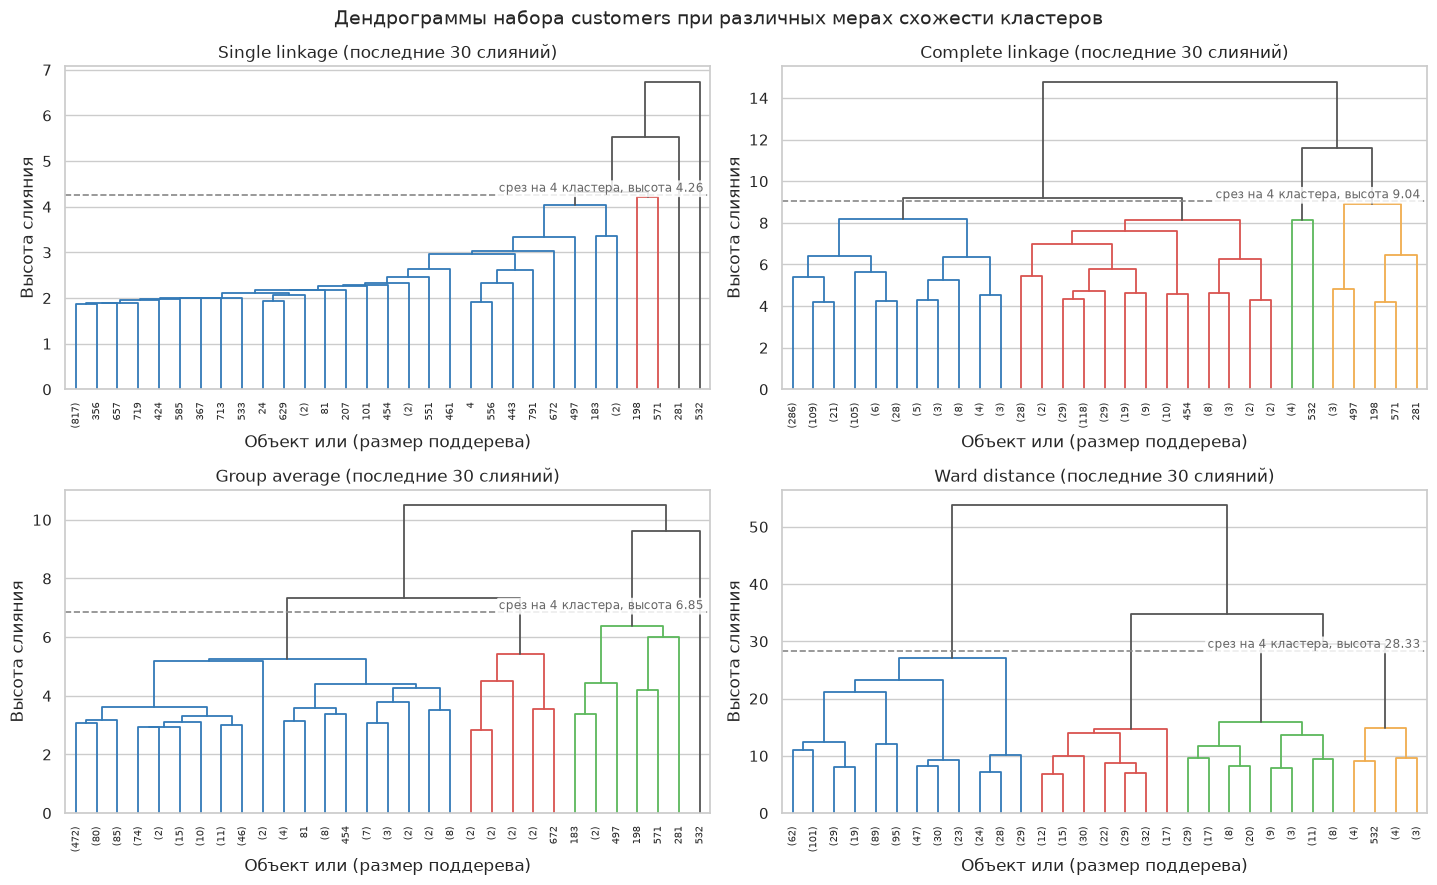

In [5]:
PALETTE = ["#337ab7", "#d9534f", "#5cb85c", "#f0ad4e", "#9b59b6",
           "#17a2b8", "#e83e8c", "#6c757d", "#8c564b"]


def plot_dendrogram(Z, ax, n_clusters=None, truncate=None, leaf_labels=True,
                    title=""):
    """
    Дендрограмма по матрице слияний Z.
      n_clusters — во сколько цветов красить поддеревья (срез на k кластеров)
      truncate   — показывать только последние truncate слияний
    """
    n = len(Z) + 1
    first_shown = 0 if truncate is None else n - 1 - truncate
    inner = set(range(n + first_shown, 2 * n - 1))      # узлы, которые ещё раскрываем
    is_leaf = lambda v: v < n or v not in inner
    sizes = np.concatenate([np.ones(n), Z[:, 3]])

    order = []                                          # порядок листьев слева направо
    def collect(v):
        if is_leaf(v):
            order.append(v)
        else:
            collect(int(Z[v - n][0]))
            collect(int(Z[v - n][1]))
    collect(2 * n - 2)
    x_leaf = {v: 10.0 * i + 5.0 for i, v in enumerate(order)}

    threshold, colors = None, {}
    if n_clusters:                                      # высота среза на k кластеров
        threshold = (Z[n - n_clusters - 1, 2] + Z[n - n_clusters, 2]) / 2
        groups = []
        def split(v):
            if not is_leaf(v) and Z[v - n][2] > threshold:
                split(int(Z[v - n][0]))
                split(int(Z[v - n][1]))
            else:
                groups.append(v)
        split(2 * n - 2)
        def paint(v, color):
            colors[v] = color
            if not is_leaf(v):
                paint(int(Z[v - n][0]), color)
                paint(int(Z[v - n][1]), color)
        for position, v in enumerate(groups):           # groups уже слева направо
            paint(v, PALETTE[position % len(PALETTE)])

    def draw(v):
        """Нарисовать поддерево; вернуть (x, y) его вершины."""
        if is_leaf(v):
            return x_leaf[v], 0.0
        x_a, y_a = draw(int(Z[v - n][0]))
        x_b, y_b = draw(int(Z[v - n][1]))
        height = Z[v - n][2]
        ax.plot([x_a, x_a, x_b, x_b], [y_a, height, height, y_b],
                color=colors.get(v, "#555555"), linewidth=1.3)
        return (x_a + x_b) / 2, height
    draw(2 * n - 2)

    if threshold is not None:
        ax.axhline(threshold, color="#888888", linestyle="--", linewidth=1.2)
        ax.annotate(f"срез на {n_clusters} кластера, высота {threshold:.2f}",
                    (0.99, threshold), xycoords=("axes fraction", "data"), ha="right",
                    va="bottom", fontsize=8.5, color="#666666",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
    ax.set_xlim(0, 10.0 * len(order))
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Высота слияния")
    ax.set_title(title, fontsize=12)
    ax.grid(axis="x", visible=False)
    if leaf_labels:
        ax.set_xticks([x_leaf[v] for v in order])
        ax.set_xticklabels([f"({int(sizes[v])})" if v >= n else str(v) for v in order],
                           fontsize=7, rotation=90)
        ax.set_xlabel("Объект или (размер поддерева)")
    else:
        ax.set_xticks([])
        ax.set_xlabel(f"Объекты набора ({n} шт.)")
    return order


K_CUT = 4

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))
for ax, linkage in zip(axes.ravel(), LINKAGES):
    plot_dendrogram(trees[linkage], ax, n_clusters=K_CUT, truncate=30,
                    title=f"{LINKAGE_LABEL[linkage]} (последние 30 слияний)")
fig.suptitle("Дендрограммы набора customers при различных мерах схожести кластеров",
             fontsize=14)
fig.tight_layout()
plt.show()

### Полные дендрограммы

Те же деревья целиком, без усечения. Подписи листьев опущены, зато видна общая форма
дерева — именно она и различает меры схожести.

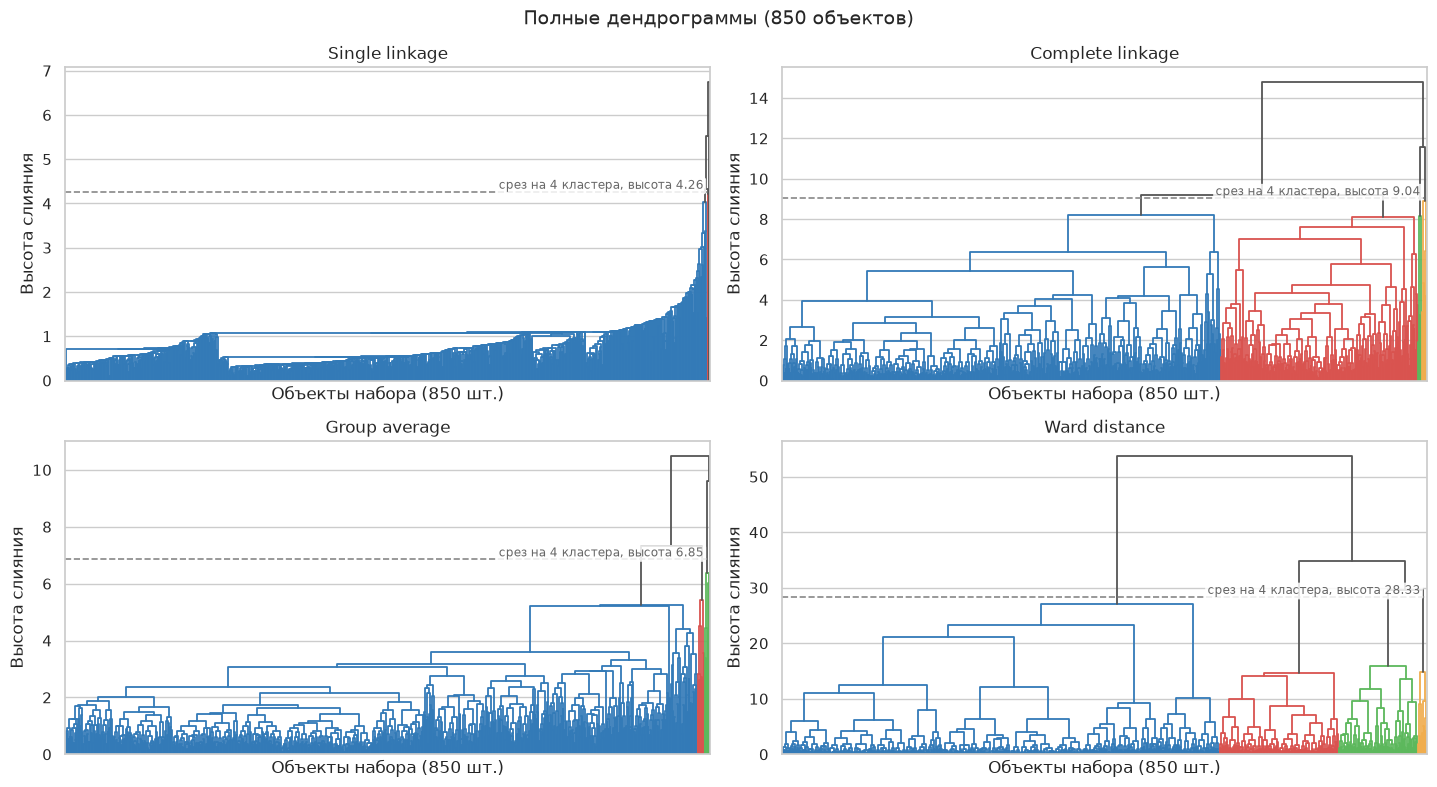

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 8))
for ax, linkage in zip(axes.ravel(), LINKAGES):
    plot_dendrogram(trees[linkage], ax, n_clusters=K_CUT, leaf_labels=False,
                    title=LINKAGE_LABEL[linkage])
fig.suptitle("Полные дендрограммы (850 объектов)", fontsize=14)
fig.tight_layout()
plt.show()

## 5. Сравнение мер схожести кластеров между собой

Сравнение ведётся по четырём направлениям: форма дерева (высоты слияний), сбалансированность
получаемого разбиения, качество разбиения по мерам ошибки из задания 1 и взаимное согласие
разбиений.

In [7]:
rows = []
for linkage in LINKAGES:
    Z = trees[linkage]
    for k in range(2, 7):
        labels = cut_tree(Z, k)
        sizes = np.bincount(labels)
        sse, total = cluster_errors(X, labels)
        rows.append({"Мера": LINKAGE_LABEL[linkage], "k": k,
                     "Размеры кластеров": sizes.tolist(),
                     "Доля крупнейшего": sizes.max() / len(X),
                     "Кластеров < 1 % набора": int((sizes < 0.01 * len(X)).sum()),
                     "SSE": sse, "E": total})

df_linkage = pd.DataFrame(rows)
df_linkage.set_index(["Мера", "k"]).round(
    {"Доля крупнейшего": 3, "SSE": 1, "E": 1})

Размеры кластеров  Доля крупнейшего  \
Мера             k                                                   
Single linkage   2                      [849, 1]             0.999   
                 3                   [848, 1, 1]             0.998   
                 4                [846, 2, 1, 1]             0.995   
                 5             [846, 1, 1, 1, 1]             0.995   
                 6          [843, 3, 1, 1, 1, 1]             0.992   
Complete linkage 2                     [838, 12]             0.986   
                 3                   [838, 7, 5]             0.986   
                 4              [578, 260, 7, 5]             0.680   
                 5           [578, 260, 5, 4, 3]             0.680   
                 6       [555, 260, 23, 5, 4, 3]             0.653   
Group average    2                      [842, 8]             0.991   
                 3                   [842, 7, 1]             0.991   
                 4                [833, 9, 7, 1]             0.980   
                 5             [833, 9, 4, 3, 1]             0.980   
                 6          [833, 9, 4, 2, 1, 1]             0.980   
Ward distance    2                    [576, 274]             0.678   
                 3               [576, 157, 117]             0.678   
                 4           [576, 157, 105, 12]             0.678   
                 5       [495, 157, 105, 81, 12]             0.582   
                 6  [395, 157, 105, 100, 81, 12]             0.465   

                    Кластеров < 1 % набора     SSE       E  
Мера             k                                          
Single linkage   2                       1  5778.3  1995.0  
                 3                       2  5624.4  1982.5  
                 4                       3  5442.3  1967.2  
                 5                       4  5433.4  1963.0  
                 6                       5  5178.0  1939.5  
Complete linkage 2                       0  5091.1  1951.8  
                 3                       2  4980.4  1933.3  
                 4                       2  4038.4  1747.2  
                 5                       3  3992.3  1740.6  
                 6                       3  3649.1  1697.7  
Group average    2                       1  5261.7  1960.9  
                 3                       2  5191.0  1951.2  
                 4                       2  4828.0  1918.6  
                 5                       3  4781.8  1911.9  
                 6                       4  4760.6  1906.4  
Ward distance    2                       0  4506.3  1775.9  
                 3                       0  3900.1  1680.5  
                 4                       0  3463.2  1643.9  
                 5                       0  3096.0  1551.2  
                 6                       0  2826.2  1480.3

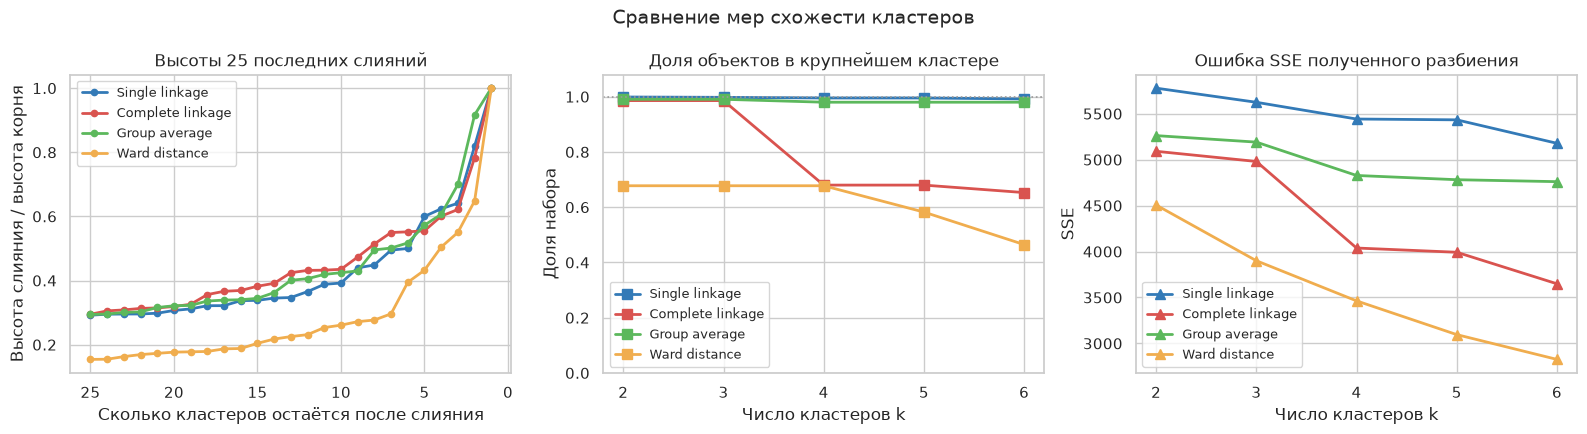

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
colors = dict(zip(LINKAGES, ["#337ab7", "#d9534f", "#5cb85c", "#f0ad4e"]))

# 1) высоты последних слияний — форма дерева
for linkage in LINKAGES:
    heights = trees[linkage][-25:, 2]
    heights = heights / heights[-1]                     # нормировка на высоту корня
    axes[0].plot(range(25, 0, -1), heights, marker="o", markersize=4.5, linewidth=2,
                 color=colors[linkage], label=LINKAGE_LABEL[linkage])
axes[0].set_title("Высоты 25 последних слияний", fontsize=12)
axes[0].set_xlabel("Сколько кластеров остаётся после слияния")
axes[0].set_ylabel("Высота слияния / высота корня")
axes[0].invert_xaxis()
axes[0].legend(fontsize=9)

# 2) сбалансированность разбиения
for linkage in LINKAGES:
    sub = df_linkage[df_linkage["Мера"] == LINKAGE_LABEL[linkage]]
    axes[1].plot(sub["k"], sub["Доля крупнейшего"], marker="s", markersize=7,
                 linewidth=2, color=colors[linkage], label=LINKAGE_LABEL[linkage])
axes[1].axhline(1.0, color="#999999", linestyle=":", linewidth=1.2)
axes[1].set_title("Доля объектов в крупнейшем кластере", fontsize=12)
axes[1].set_xlabel("Число кластеров k")
axes[1].set_ylabel("Доля набора")
axes[1].set_ylim(0, 1.08)
axes[1].set_xticks(range(2, 7))
axes[1].legend(fontsize=9)

# 3) ошибка полученного разбиения
for linkage in LINKAGES:
    sub = df_linkage[df_linkage["Мера"] == LINKAGE_LABEL[linkage]]
    axes[2].plot(sub["k"], sub["SSE"], marker="^", markersize=7, linewidth=2,
                 color=colors[linkage], label=LINKAGE_LABEL[linkage])
axes[2].set_title("Ошибка SSE полученного разбиения", fontsize=12)
axes[2].set_xlabel("Число кластеров k")
axes[2].set_ylabel("SSE")
axes[2].set_xticks(range(2, 7))
axes[2].legend(fontsize=9)

fig.suptitle("Сравнение мер схожести кластеров", fontsize=13.5)
fig.tight_layout()
plt.show()

### Кофенетическая корреляция

Количественная оценка того, насколько дерево вообще соответствует исходным расстояниям.
**Кофенетическое расстояние** между объектами $x$ и $y$ — это высота того слияния, на
котором они впервые оказались в одном кластере. Коэффициент корреляции Пирсона между
кофенетическими и исходными евклидовыми расстояниями показывает, насколько точно
дендрограмма передаёт реальную геометрию набора: чем ближе к 1, тем меньше искажение.

In [9]:
def cophenetic_distances(Z):
    """Для каждой пары объектов — высота слияния, на котором они попали в один кластер."""
    n = len(Z) + 1
    members = {i: [i] for i in range(n)}
    C = np.zeros((n, n))
    for step, (a, b, height, _) in enumerate(Z):
        left, right = members.pop(int(a)), members.pop(int(b))
        C[np.ix_(left, right)] = C[np.ix_(right, left)] = height
        members[n + step] = left + right
    return C


D_original = pairwise_distances(X, X)
triu = np.triu_indices(len(X), k=1)

coph = {}
for linkage in LINKAGES:
    C = cophenetic_distances(trees[linkage])
    coph[linkage] = float(np.corrcoef(D_original[triu], C[triu])[0, 1])

for linkage in LINKAGES:
    print(f"{LINKAGE_LABEL[linkage]:<18} кофенетическая корреляция = {coph[linkage]:.3f}")

Single linkage     кофенетическая корреляция = 0.836
Complete linkage   кофенетическая корреляция = 0.660
Group average      кофенетическая корреляция = 0.852
Ward distance      кофенетическая корреляция = 0.496


## 6. Сравнение с результатами задания 1

Для сравнения воспроизводятся алгоритмы k-Means и k-Medoids из задания 1 (реализация
та же: инициализация k-means++, 10 запусков, выбор лучшего по ошибке). Все разбиения
строятся при $k = 4$ — значении, найденном по методу локтя в задании 1.

Сравниваются: ошибка разбиения по обеим мерам ($SSE$ и $E$), сбалансированность и
взаимное согласие разбиений по **скорректированному индексу Рэнда** (ARI): 1 — разбиения
совпадают, около 0 — согласие на уровне случайного.

In [10]:
def kmeans_pp_init(X, k, rng, D=None):
    idx = [int(rng.integers(len(X)))]
    d2 = (D[idx[0]] ** 2 if D is not None else ((X - X[idx[0]]) ** 2).sum(1))
    for _ in range(k - 1):
        total = d2.sum()
        p = d2 / total if total > 0 else np.full(len(X), 1 / len(X))
        j = int(rng.choice(len(X), p=p))
        idx.append(j)
        d2 = np.minimum(d2, D[j] ** 2 if D is not None else ((X - X[j]) ** 2).sum(1))
    return np.array(idx)


def kmeans(X, k, seed=RANDOM_SEED, n_init=10, max_iter=300, tol=1e-9):
    """k-средних (реализация из задания 1)."""
    rng = np.random.default_rng(seed)
    best, best_sse = None, np.inf
    for _ in range(n_init):
        centers = X[kmeans_pp_init(X, k, rng)].copy()
        prev = np.inf
        for _ in range(max_iter):
            D = pairwise_distances(X, centers)
            labels = D.argmin(axis=1)
            sse = (D[np.arange(len(X)), labels] ** 2).sum()
            for j in range(k):
                members = labels == j
                centers[j] = (X[members].mean(axis=0) if members.any()
                              else X[D.min(axis=1).argmax()])
            if prev - sse <= tol:
                break
            prev = sse
        D = pairwise_distances(X, centers)
        labels = D.argmin(axis=1)
        sse = float((D[np.arange(len(X)), labels] ** 2).sum())
        if sse < best_sse:
            best, best_sse = labels, sse
    return best


def kmedoids(X, k, seed=RANDOM_SEED, n_init=10, max_iter=300):
    """k-медоидов (реализация из задания 1)."""
    rng = np.random.default_rng(seed)
    D = pairwise_distances(X, X)
    rows_idx = np.arange(len(X))
    best, best_cost = None, np.inf
    for _ in range(n_init):
        medoids = kmeans_pp_init(X, k, rng, D=D)
        prev = np.inf
        for _ in range(max_iter):
            labels = D[:, medoids].argmin(axis=1)
            cost = D[rows_idx, medoids[labels]].sum()
            for j in range(k):
                members = np.flatnonzero(labels == j)
                if len(members):
                    medoids[j] = members[D[np.ix_(members, members)].sum(axis=0).argmin()]
            if prev - cost <= 1e-12:
                break
            prev = cost
        labels = D[:, medoids].argmin(axis=1)
        cost = float(D[rows_idx, medoids[labels]].sum())
        if cost < best_cost:
            best, best_cost = labels, cost
    return best


def adjusted_rand_index(a, b):
    """Мера согласия двух разбиений: 1 — совпадают, ~0 — согласие на уровне случайного."""
    a, b = np.asarray(a), np.asarray(b)
    table = np.zeros((a.max() + 1, b.max() + 1))
    np.add.at(table, (a, b), 1)
    comb2 = lambda x: x * (x - 1) / 2
    sum_ij, sum_a, sum_b = (comb2(table).sum(), comb2(table.sum(1)).sum(),
                            comb2(table.sum(0)).sum())
    expected = sum_a * sum_b / comb2(len(a))
    return float((sum_ij - expected) / ((sum_a + sum_b) / 2 - expected))


partitions = {LINKAGE_LABEL[m]: cut_tree(trees[m], K_CUT) for m in LINKAGES}
partitions["k-Means"] = kmeans(X, K_CUT)
partitions["k-Medoids"] = kmedoids(X, K_CUT)

LINKAGE_BY_LABEL = {label: key for key, label in LINKAGE_LABEL.items()}

rows = []
for name, labels in partitions.items():
    sse, total = cluster_errors(X, labels)
    sizes = np.bincount(labels)
    key = LINKAGE_BY_LABEL.get(name)
    rows.append({"Метод": name, "Размеры кластеров": sizes.tolist(),
                 "SSE": round(sse, 1), "E": round(total, 1),
                 "Доля крупнейшего": round(sizes.max() / len(X), 3),
                 "Кофенетическая корр.": round(coph[key], 3) if key else None})

pd.DataFrame(rows).set_index("Метод")

,Размеры кластеров,SSE,E,Доля крупнейшего,Кофенетическая корр.
Метод,,,,,
Single linkage,"[846, 2, 1, 1]",5442.3,1967.2,0.995,0.836
Complete linkage,"[578, 260, 7, 5]",4038.4,1747.2,0.680,0.660
Group average,"[833, 9, 7, 1]",4828.0,1918.6,0.980,0.852
Ward distance,"[576, 157, 105, 12]",3463.2,1643.9,0.678,0.496
k-Means,"[150, 217, 54, 429]",3232.7,1576.0,0.505,NaN
k-Medoids,"[247, 131, 215, 257]",3417.2,1495.4,0.302,NaN


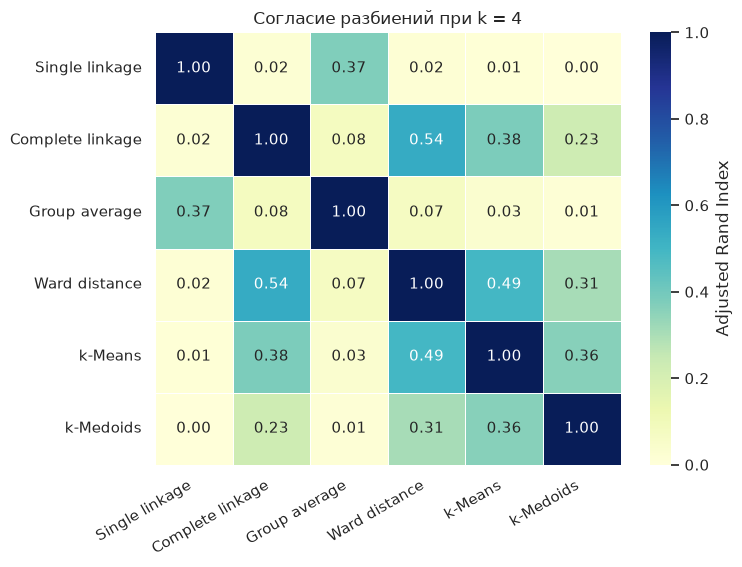

In [11]:
names = list(partitions)
ari_matrix = pd.DataFrame(
    [[adjusted_rand_index(partitions[a], partitions[b]) for b in names] for a in names],
    index=names, columns=names)

fig, ax = plt.subplots(figsize=(7.6, 5.8))
sns.heatmap(ari_matrix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "Adjusted Rand Index"})
ax.set_title(f"Согласие разбиений при k = {K_CUT}", fontsize=12.5)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.show()

### Разбиения в проекции на главные компоненты

Та же проекция PCA, что и в задании 1: два ортогональных направления максимальной
дисперсии, вычисленные через сингулярное разложение центрированной матрицы. Цвет точки
отражает принадлежность кластеру.

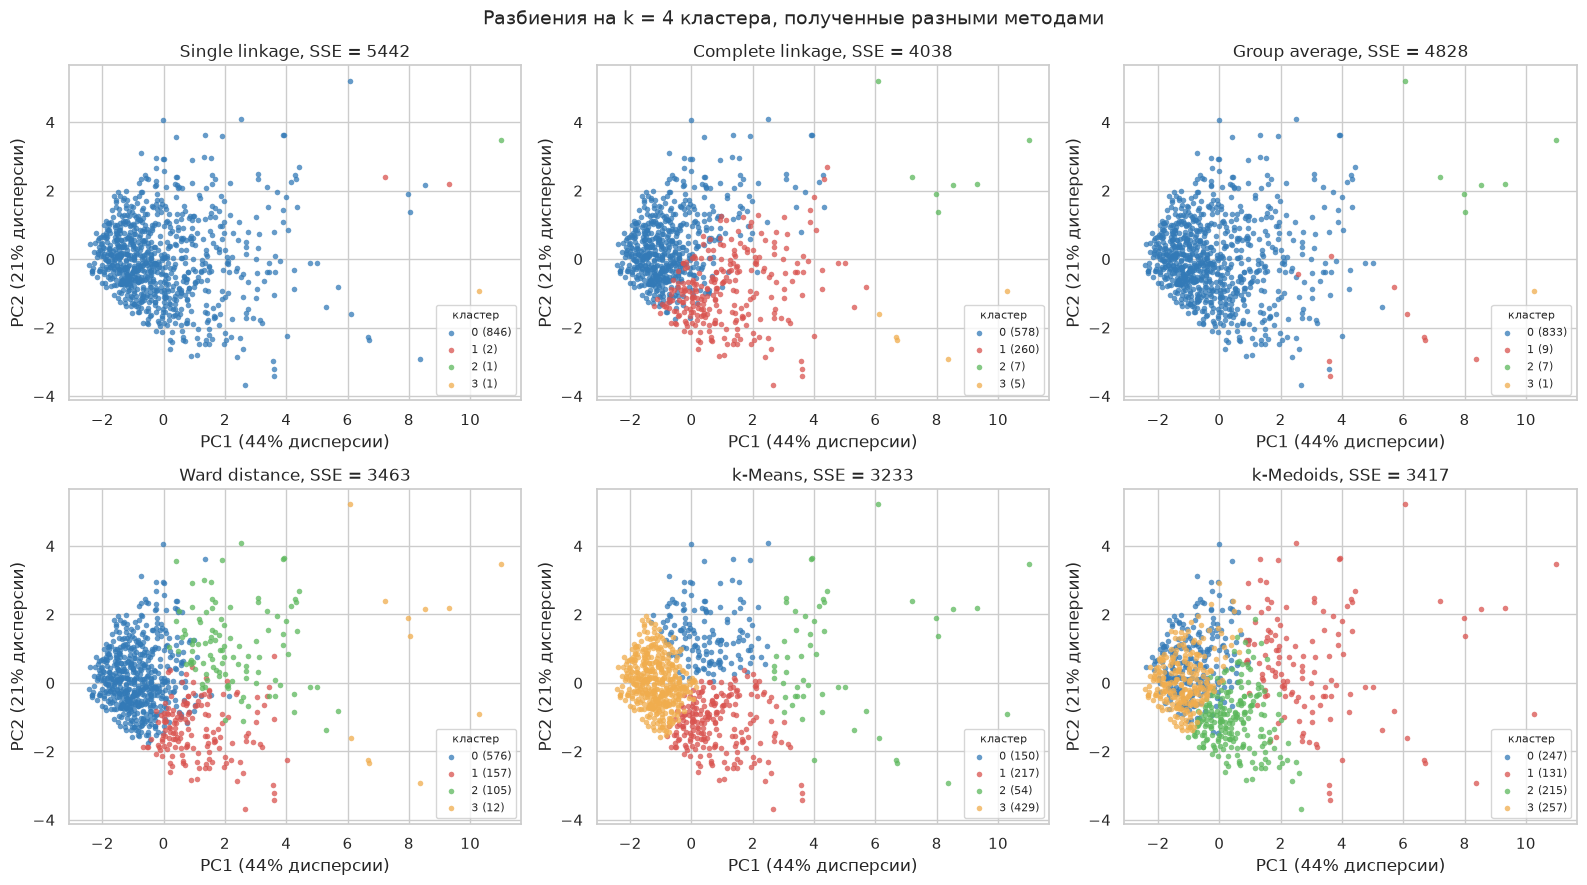

In [12]:
def fit_pca(X):
    center = X.mean(axis=0)
    _, S, Vt = np.linalg.svd(X - center, full_matrices=False)
    components = Vt[:2] * np.sign(Vt[:2, np.abs(Vt[:2]).argmax(axis=1)].diagonal())[:, None]
    return (lambda Y: (Y - center) @ components.T), S ** 2 / (S ** 2).sum()


project, var_ratio = fit_pca(X)
P = project(X)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, labels) in zip(axes.ravel(), partitions.items()):
    for j in range(labels.max() + 1):
        m = labels == j
        ax.scatter(P[m, 0], P[m, 1], s=16, alpha=0.75, linewidths=0,
                   color=PALETTE[j % len(PALETTE)], label=f"{j} ({m.sum()})")
    sse, _ = cluster_errors(X, labels)
    ax.set_title(f"{name}, SSE = {sse:.0f}", fontsize=12)
    ax.set_xlabel(f"PC1 ({var_ratio[0]:.0%} дисперсии)")
    ax.set_ylabel(f"PC2 ({var_ratio[1]:.0%} дисперсии)")
    ax.legend(fontsize=8, title="кластер", title_fontsize=8)

fig.suptitle(f"Разбиения на k = {K_CUT} кластера, полученные разными методами", fontsize=14)
fig.tight_layout()
plt.show()

### Содержательная проверка

Атрибут `Defaulted` (факт банкротства) в кластеризации не участвовал. Разброс доли
банкротов между кластерами показывает, насколько разбиение улавливает реальную структуру
кредитного риска: чем сильнее кластеры различаются по этому показателю, тем содержательнее
разбиение.

In [13]:
summary = []
for name, labels in partitions.items():
    shares = df["Defaulted"].groupby(labels).mean()
    counts = np.bincount(labels)
    big = counts >= 0.05 * len(X)          # кластеры мельче 5 % набора не показательны
    summary.append({"Метод": name,
                    "Крупных кластеров (>= 5 %)": int(big.sum()),
                    "Доля банкротов, min": round(shares[big].min(), 3),
                    "Доля банкротов, max": round(shares[big].max(), 3),
                    "Размах": round(shares[big].max() - shares[big].min(), 3)})

print(f"Доля банкротов по набору в целом: {df['Defaulted'].mean():.3f}")
display(pd.DataFrame(summary).set_index("Метод"))

display(pd.DataFrame(X_raw, columns=FEATURES)
        .groupby(partitions["Ward distance"]).mean().round(2)
        .assign(**{"Объектов": np.bincount(partitions["Ward distance"]),
                   "Доля банкротов": df["Defaulted"]
                   .groupby(partitions["Ward distance"]).mean().round(3)})
        .rename_axis("Ward: кластер"))

Доля банкротов по набору в целом: 0.261


,Крупных кластеров (>= 5 %),"Доля банкротов, min","Доля банкротов, max",Размах
Метод,,,,
Single linkage,1,0.258,0.258,0.000
Complete linkage,2,0.111,0.316,0.205
Group average,1,0.256,0.256,0.000
Ward distance,3,0.033,0.391,0.358
k-Means,4,0.083,0.512,0.428
k-Medoids,4,0.096,0.373,0.277


,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,DebtIncomeRatio,Объектов,Доля банкротов
Ward: кластер,,,,,,,,,
0,32.16,1.70,5.23,30.49,0.90,1.80,9.27,576,0.286
1,41.83,1.45,17.35,75.99,1.76,3.17,7.13,157,0.033
2,39.30,2.13,11.96,72.43,3.83,8.30,18.74,105,0.391
3,46.25,1.67,23.92,214.50,12.13,17.64,18.21,12,0.778


## 7. Выводы

### Как мера схожести определяет форму дерева

Четыре меры дали качественно разные деревья, и лучше всего это видно на полных
дендрограммах.

**Single linkage** демонстрирует классический **эффект цепочек** (chaining): дерево
вырождается в «лестницу», где один гигантский кластер последовательно присоединяет к себе
по одному объекту. Срез на любое число кластеров от 2 до 6 даёт одно и то же по сути
разбиение — 846/2/1/1 при $k = 4$, то есть 99.5 % набора в одном кластере, а остальные
«кластеры» это отдельные выбросы. Причина прямо следует из определения: расстояние между
кластерами равно расстоянию между **ближайшей** парой их объектов, поэтому две плотные
группы, соединённые цепочкой из нескольких промежуточных точек, сливаются очень рано.

**Group average** страдает тем же, но слабее: 833/9/7/1. Усреднение по всем парам делает
меру менее чувствительной к единственному «мостику», однако в наборе `customers` плотное
ядро вообще не имеет разрывов (это видно на точечных графиках задания 1), и усреднённого
расстояния не хватает, чтобы его рассечь.

**Complete linkage** впервые даёт осмысленное деление — 578/260/7/5: расстояние
определяется **самой далёкой** парой объектов, поэтому мера штрафует за разброс внутри
кластера и цепочки не образуются. Платой становится чувствительность к выбросам: 12
объектов отрезаются в два микрокластера.

**Ward distance** даёт самое сбалансированное разбиение — 576/157/105/12 при $k = 4$ и
крупнейший кластер в 46.5 % при $k = 6$. Это ожидаемо: мера Ward минимизирует прирост
внутрикластерной суммы квадратов, то есть ровно тот функционал $SSE$, который минимизирует
k-Means, — только жадно и иерархически.

### Кофенетическая корреляция: что она на самом деле измеряет

Здесь получен результат, который на первый взгляд противоречит всему сказанному выше:

| Мера | Кофенетическая корреляция | SSE при $k = 4$ |
|---|---|---|
| Group average | **0.852** | 4828.0 |
| Single linkage | 0.836 | 5442.3 |
| Complete linkage | 0.660 | 4038.4 |
| Ward distance | **0.496** | **3463.2** |

Меры с наилучшей кофенетической корреляцией дают наихудшие разбиения, и наоборот.
Противоречия нет: кофенетическая корреляция измеряет, насколько точно **дерево**
воспроизводит исходные попарные расстояния, а не насколько полезно получаемое **разбиение**.
Group average по построению усредняет расстояния и потому хорошо их воспроизводит; Ward же
оперирует не расстояниями между объектами, а приростом дисперсии, его высоты слияния имеют
другую природу и другой масштаб (высота корня 53.7 против 10.5 у group average), поэтому
коррелировать с евклидовыми расстояниями они не обязаны. Практический вывод: кофенетическая
корреляция — характеристика точности дерева как модели расстояний, и выбирать по ней меру
схожести для задачи кластеризации нельзя.

### Сравнение с результатами задания 1

При $k = 4$ все шесть разбиений упорядочиваются так:

| Метод | SSE | E | Размеры кластеров |
|---|---|---|---|
| k-Means | **3232.7** | 1576.0 | 150/217/54/429 |
| k-Medoids | 3417.2 | **1495.4** | 247/131/215/257 |
| Ward distance | 3463.2 | 1643.9 | 576/157/105/12 |
| Complete linkage | 4038.4 | 1747.2 | 578/260/7/5 |
| Group average | 4828.0 | 1918.6 | 833/9/7/1 |
| Single linkage | 5442.3 | 1967.2 | 846/2/1/1 |

**Итеративные методы выигрывают у иерархических по обеим мерам ошибки.** Причина
принципиальная: слияния в агломеративной схеме жадные и необратимые — однажды объединённые
объекты уже никогда не будут разделены, тогда как k-Means на каждой итерации заново
переназначает все объекты и может исправить неудачное раннее решение. Ближе всех к k-Means
подходит именно Ward (SSE больше лишь на 7 %), что естественно: он оптимизирует тот же
функционал.

Согласие разбиений (ARI) подтверждает ту же картину: Ward — k-Means даёт 0.49, это
наибольшее согласие иерархического метода с итеративным; Ward — Complete linkage 0.54;
Single linkage и Group average согласуются между собой (0.37), но практически не
согласуются ни с чем другим (ARI от 0.01 до 0.08) — они описывают не структуру данных, а
одно и то же вырожденное разбиение «всё в одном кластере плюс выбросы».

Содержательная проверка по не участвовавшему в кластеризации атрибуту `Defaulted` даёт тот
же порядок. Размах доли банкротов между крупными (не менее 5 % набора) кластерами: k-Means
0.428, Ward 0.358, k-Medoids 0.277, Complete linkage 0.205, а Single linkage и Group average
дают 0.000 — просто потому, что крупный кластер у них ровно один и различать нечего.

При этом у иерархии есть и собственное преимущество: кластер 3 меры Ward — это 12 клиентов
с доходом 214.5 K\$, долгами 12.1 + 17.6 и **долей банкротов 0.778**. Это предельная группа
риска, которую k-Means растворяет внутри своего кластера из 54 состоятельных клиентов.
Дендрограмма позволяет увидеть такие мелкие, но содержательно важные группы, не фиксируя
$k$ заранее.

### Общие выводы

* Выбор меры схожести кластеров влияет на результат сильнее, чем выбор числа кластеров:
  при одном и том же $k = 4$ разброс SSE между мерами (3463 … 5442) больше, чем разброс
  SSE у k-Means при изменении $k$ от 4 до 12 (3233 … 1872).
* Для данных без явных разрывов — а набор `customers` именно таков — пригодны меры,
  штрафующие разброс внутри кластера: **Ward** и, с оговорками, **Complete linkage**.
  Single linkage и Group average на таких данных вырождаются в цепочки. Single linkage
  уместен там, где кластеры заведомо разделены и могут иметь произвольную вытянутую форму.
* Иерархическая кластеризация **детерминирована**: она не зависит от случайной
  инициализации и при повторном запуске даёт тот же результат. Это выгодно отличает её от
  k-Medoids, у которого в задании 1 ARI между запусками на одних и тех же данных составил
  всего 0.45.
* Главное ограничение — ресурсы: алгоритму нужна матрица расстояний $n \times n$, то есть
  $O(n^2)$ памяти (на 850 объектах это доли секунды, но уже на $10^5$ объектов — десятки
  гигабайт), тогда как k-Means требует $O(nkd)$ операций на итерацию и матрицы расстояний
  не хранит.
* Практически разумна связка методов: **Ward** — чтобы по дендрограмме увидеть структуру
  данных и выбрать $k$ без априорных предположений, затем **k-Means** — чтобы уточнить
  разбиение, исправив жадные решения, принятые на ранних слияниях.